# Parte 3 — Modelo + Simulación Monte Carlo

1. Logistic Regression (baseline) vs GradientBoosting
2. Importancia de features
3. Simulación Monte Carlo — 10.000 torneos
4. Exporta `outputs/predicciones_2026.csv`

**Fases WC2026:** Grupos → 16avos de final → Octavos → Cuartos → Semis → Final

In [1]:
import sys
sys.path.append("..")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path
from src.features import FEATURE_COLS
from src.model import train, feature_importance, save_model
from src.simulator import precompute_match_probs, simular_torneo
from src.data_loader import load_wc2026_teams
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120
OUTPUTS = Path("../outputs")
GRAFICOS = OUTPUTS / "graficos"


## 1. Dataset de entrenamiento

In [2]:
df = pd.read_csv("../data/processed/features_train.csv")
X, y = df[FEATURE_COLS], df["result"]
print(f"Partidos: {len(df):,}  |  Features: {len(FEATURE_COLS)}")
print(y.value_counts().rename({0:"Derrota", 1:"Empate", 2:"Victoria"}))


Partidos: 10,636  |  Features: 10
result
Victoria    5255
Derrota     3045
Empate      2336
Name: count, dtype: int64


## 2. Baseline — Logistic Regression

In [3]:
lr_model, X_test_lr, y_test_lr, scaler_lr = train(X, y, model_type="lr")



Modelo: LR
Accuracy: 0.5982
Log-loss: 0.8844
              precision    recall  f1-score   support

     Derrota       0.55      0.57      0.56       609
      Empate       0.50      0.00      0.00       467
    Victoria       0.62      0.88      0.73      1052

    accuracy                           0.60      2128
   macro avg       0.56      0.48      0.43      2128
weighted avg       0.57      0.60      0.52      2128



## 3. GradientBoosting

In [4]:
gbm_model, X_test_gbm, y_test_gbm, _ = train(X, y, model_type="gbm")
save_model(gbm_model, name="model_gbm.joblib")



Modelo: GBM
Accuracy: 0.5935
Log-loss: 0.9065
              precision    recall  f1-score   support

     Derrota       0.56      0.54      0.55       609
      Empate       0.21      0.04      0.07       467
    Victoria       0.63      0.87      0.73      1052

    accuracy                           0.59      2128
   macro avg       0.47      0.48      0.45      2128
weighted avg       0.52      0.59      0.53      2128

Modelo guardado: outputs/model_gbm.joblib


## 4. Importancia de features (GBM)

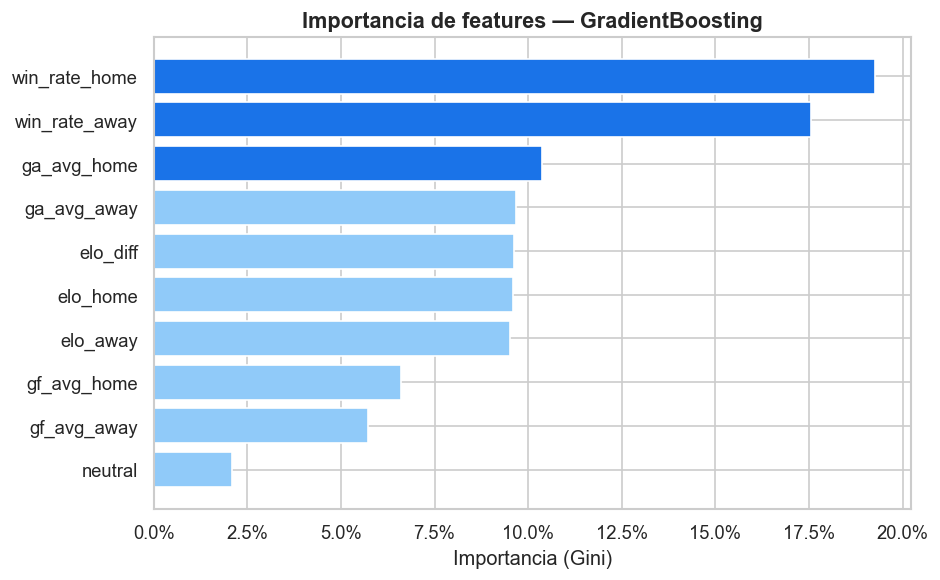

      feature  importance
win_rate_home    0.192650
win_rate_away    0.175568
  ga_avg_home    0.103593
  ga_avg_away    0.096720
     elo_diff    0.096084
     elo_home    0.095983
     elo_away    0.095237
  gf_avg_home    0.066127
  gf_avg_away    0.057158
      neutral    0.020879


In [5]:
imp_df = feature_importance(gbm_model, FEATURE_COLS)
fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#1a73e8" if i < 3 else "#90CAF9" for i in range(len(imp_df))]
ax.barh(imp_df["feature"][::-1], imp_df["importance"][::-1], color=colors[::-1], edgecolor="white")
ax.set_title("Importancia de features — GradientBoosting", fontsize=13, fontweight="bold")
ax.set_xlabel("Importancia (Gini)")
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.tight_layout()
plt.savefig(GRAFICOS / "feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print(imp_df.to_string(index=False))


## 5. Matrices de confusión — LR vs GBM

C:\Users\bruno\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


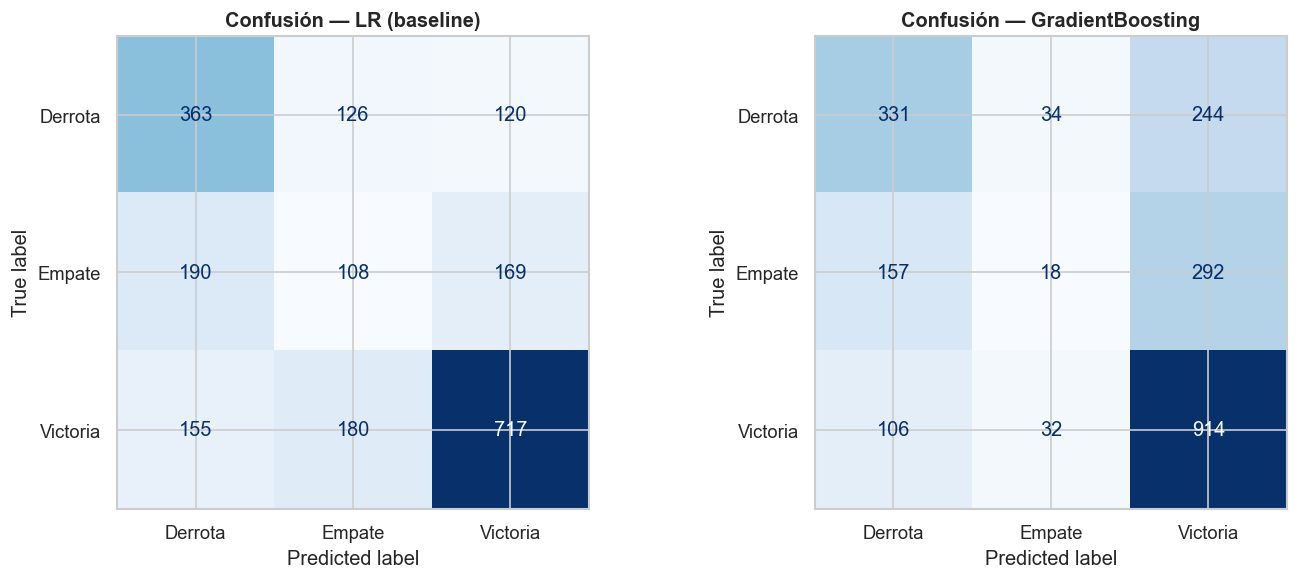

In [6]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
labels = ["Derrota", "Empate", "Victoria"]
X_lr_sc = scaler_lr.transform(X_test_lr) if scaler_lr else X_test_lr
for ax, model, Xt, yt, name in [
    (axes[0], lr_model, X_lr_sc, y_test_lr, "LR (baseline)"),
    (axes[1], gbm_model, X_test_gbm, y_test_gbm, "GradientBoosting"),
]:
    cm = confusion_matrix(yt, model.predict(Xt))
    ConfusionMatrixDisplay(cm, display_labels=labels).plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"Confusión — {name}", fontweight="bold")
plt.tight_layout()
plt.savefig(GRAFICOS / "confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. Simulación Monte Carlo — 10.000 torneos

**Optimización:** Pre-calculamos las probabilidades de los 2.256 enfrentamientos posibles en un solo batch call. La simulación solo hace `np.random.choice` — sin llamadas al modelo durante el loop.

In [7]:
features_2026 = pd.read_csv("../data/processed/features_2026.csv")
print("Pre-calculando probabilidades...")
probs_dict = precompute_match_probs(gbm_model, features_2026)
print(f"  {len(probs_dict)} pares pre-calculados")

equipos_df = load_wc2026_teams()
grupos = {g: equipos_df[equipos_df["grupo"]==g]["equipo"].tolist()
          for g in sorted(equipos_df["grupo"].unique())}
print("\nGrupos WC2026:")
for g, eq in grupos.items():
    print(f"  Grupo {g}: {eq}")


Pre-calculando probabilidades...
  2256 pares pre-calculados

Grupos WC2026:
  Grupo A: ['México', 'Sudáfrica', 'Corea del Sur', 'Chequia']
  Grupo B: ['Canadá', 'Suiza', 'Catar', 'Bosnia Herzegovina']
  Grupo C: ['Brasil', 'Marruecos', 'Haití', 'Escocia']
  Grupo D: ['Estados Unidos', 'Paraguay', 'Australia', 'Turquía']
  Grupo E: ['Alemania', 'Curazao', 'Costa de Marfil', 'Ecuador']
  Grupo F: ['Países Bajos', 'Japón', 'Suecia', 'Túnez']
  Grupo G: ['Bélgica', 'Egipto', 'Irán', 'Nueva Zelanda']
  Grupo H: ['España', 'Cabo Verde', 'Arabia Saudita', 'Uruguay']
  Grupo I: ['Francia', 'Senegal', 'Noruega', 'Irak']
  Grupo J: ['Argentina', 'Argelia', 'Austria', 'Jordania']
  Grupo K: ['Portugal', 'Congo DR', 'Uzbekistán', 'Colombia']
  Grupo L: ['Inglaterra', 'Croacia', 'Ghana', 'Panamá']


In [8]:
N_SIMS = 10_000
print(f"Simulando {N_SIMS:,} torneos...")
resultados = simular_torneo(grupos, probs_dict, n=N_SIMS)
resultados.to_csv(OUTPUTS / "predicciones_2026.csv", index=False)
print("Guardado: outputs/predicciones_2026.csv")


Simulando 10,000 torneos...


Guardado: outputs/predicciones_2026.csv


## 7. Tabla completa de resultados

In [9]:
cols = ["equipo","clasifica","16avos","octavos","cuartos","semis","final","campeon"]
display_df = resultados[cols].copy()
for c in cols[1:]:
    display_df[c] = display_df[c].map(lambda x: f"{x*100:.1f}%")
print("TOP 20:")
print(display_df.head(20).to_string(index=False))


TOP 20:
         equipo clasifica 16avos octavos cuartos semis final campeon
     Inglaterra     97.4%  97.4%   73.1%   49.4% 25.9% 18.6%   10.5%
      Argentina     94.6%  94.6%   61.9%   36.7% 24.9% 17.2%    9.1%
         España     97.7%  97.7%   60.6%   42.3% 21.9% 14.4%    8.7%
        Francia     94.2%  94.2%   60.8%   37.7% 24.8% 16.6%    8.5%
          Japón     80.1%  80.1%   53.2%   33.4% 21.7% 13.4%    8.4%
      Marruecos     91.0%  91.0%   53.7%   32.0% 16.6%  8.8%    5.0%
   Países Bajos     86.1%  86.1%   52.5%   26.2% 15.8%  8.4%    4.6%
       Alemania     92.9%  92.9%   49.3%   27.9% 15.8%  8.0%    4.2%
         México     85.5%  85.5%   51.6%   29.0% 16.1%  7.2%    3.5%
        Turquía     93.5%  93.5%   51.6%   30.5% 19.8%  8.7%    3.4%
          Suiza     92.3%  92.3%   52.4%   29.6% 15.4%  6.9%    3.0%
        Noruega     75.6%  75.6%   37.4%   18.0%  9.4%  4.6%    2.5%
  Corea del Sur     80.3%  80.3%   47.4%   27.0% 13.4%  5.6%    2.5%
Costa de Marfil     74.7% 

## 8. Candidatos al título — Top 15

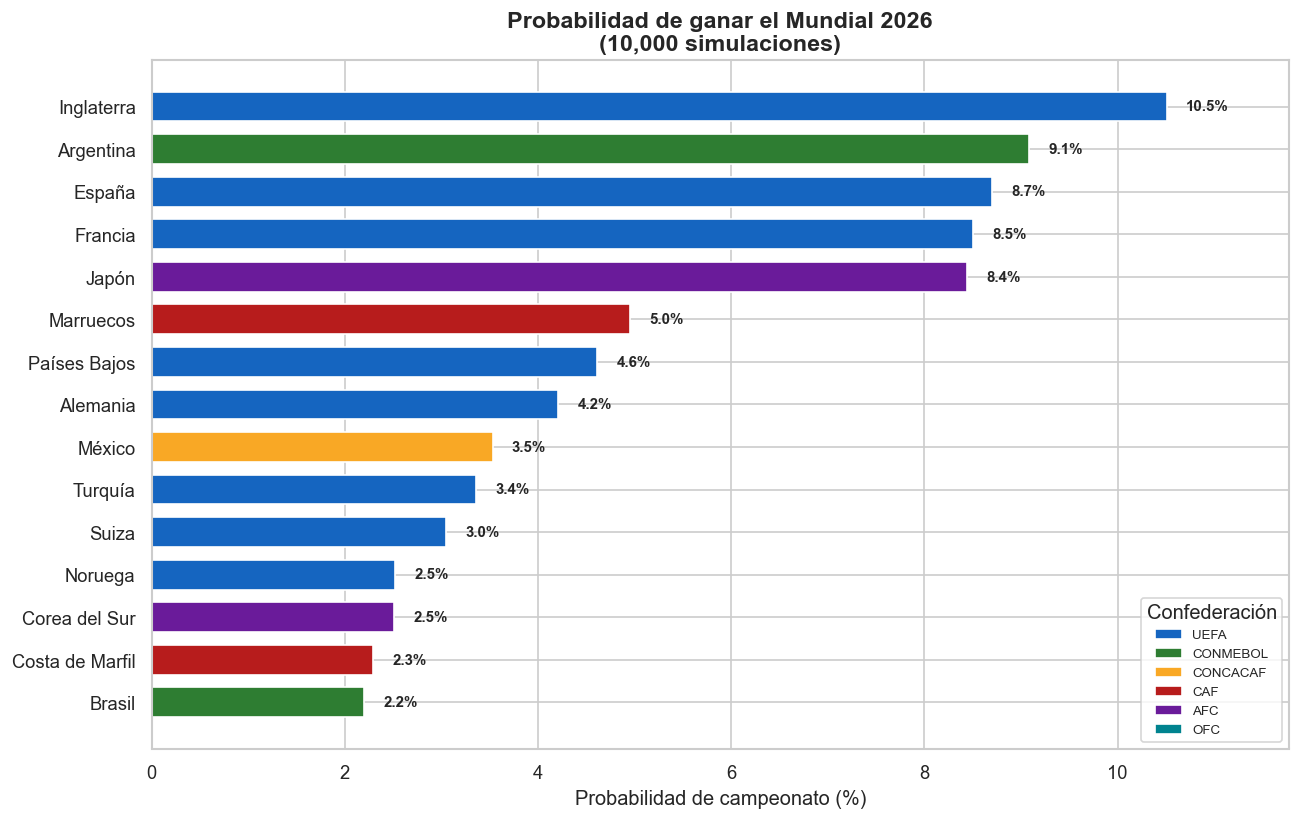

In [10]:
conf_colors = {"UEFA":"#1565C0","CONMEBOL":"#2E7D32","CONCACAF":"#F9A825",
               "CAF":"#B71C1C","AFC":"#6A1B9A","OFC":"#00838F"}
equipo_conf = dict(zip(equipos_df["equipo"], equipos_df["confederacion"]))
top15 = resultados.head(15)
colors_b = [conf_colors.get(equipo_conf.get(e,""),"#607D8B") for e in top15["equipo"]]
fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(top15["equipo"][::-1], top15["campeon"][::-1]*100,
               color=colors_b[::-1], edgecolor="white", height=0.7)
for bar, val in zip(bars, top15["campeon"][::-1]*100):
    ax.text(val+0.2, bar.get_y()+bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=9, fontweight="bold")
ax.set_title(f"Probabilidad de ganar el Mundial 2026\n({N_SIMS:,} simulaciones)",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Probabilidad de campeonato (%)")
ax.margins(x=0.12)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor=c, label=k) for k,c in conf_colors.items()],
          loc="lower right", title="Confederación", fontsize=8)
plt.tight_layout()
plt.savefig(GRAFICOS / "predicciones_campeon.png", dpi=150, bbox_inches="tight")
plt.show()


## 9. Heatmap — Probabilidades por ronda (Top 20)

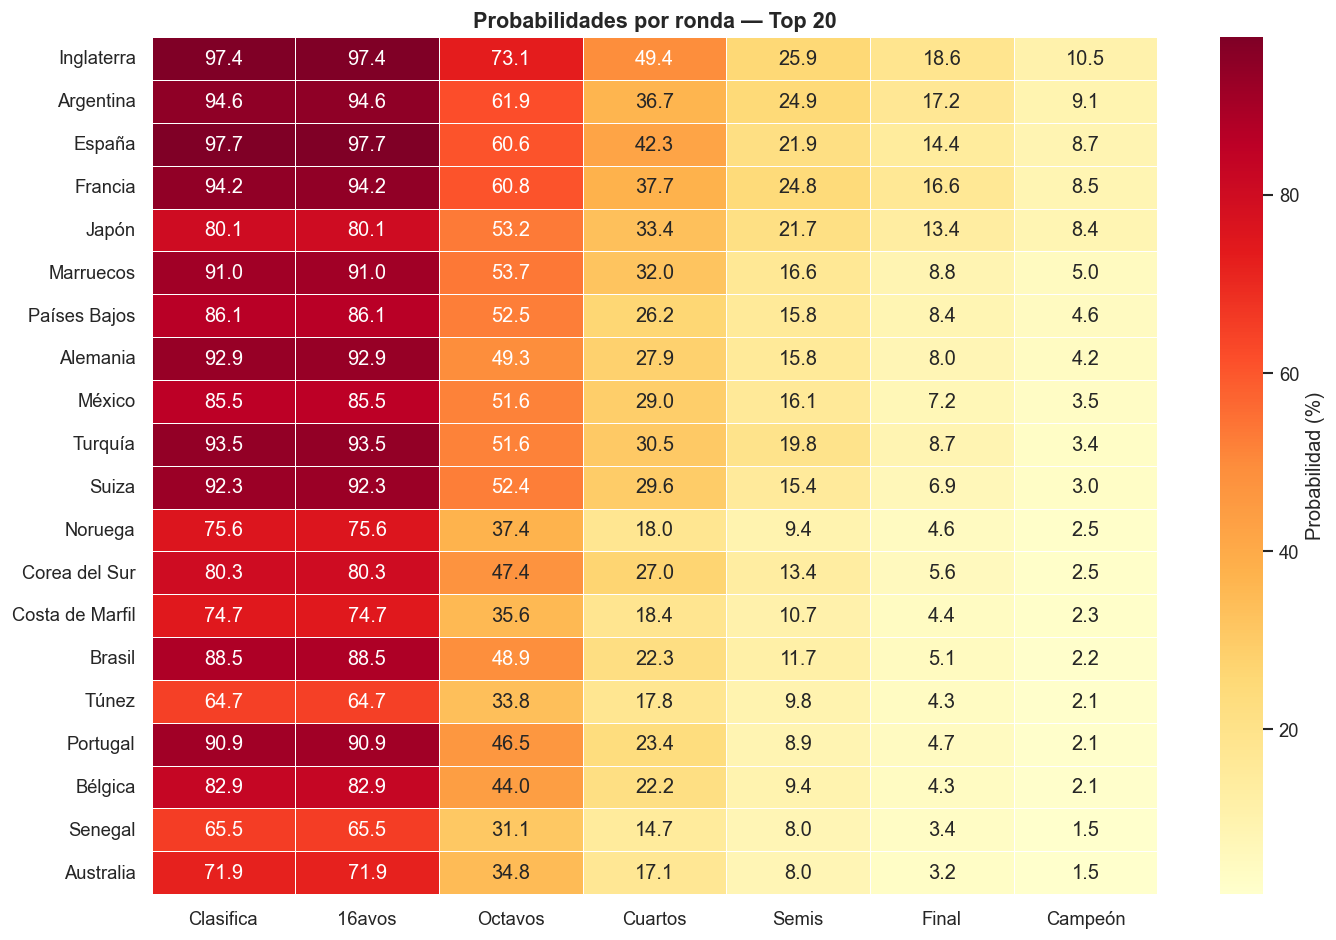

In [11]:
rondas = ["clasifica","16avos","octavos","cuartos","semis","final","campeon"]
labels_r = ["Clasifica","16avos","Octavos","Cuartos","Semis","Final","Campeón"]
heat = resultados.head(20).set_index("equipo")[rondas] * 100
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(heat, annot=True, fmt=".1f", cmap="YlOrRd", linewidths=0.5, ax=ax,
            cbar_kws={"label":"Probabilidad (%)"}, xticklabels=labels_r)
ax.set_title("Probabilidades por ronda — Top 20", fontsize=13, fontweight="bold")
ax.set_ylabel("")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.savefig(GRAFICOS / "heatmap_probabilidades.png", dpi=150, bbox_inches="tight")
plt.show()


## 10. Probabilidad de clasificar a 16avos — por grupo

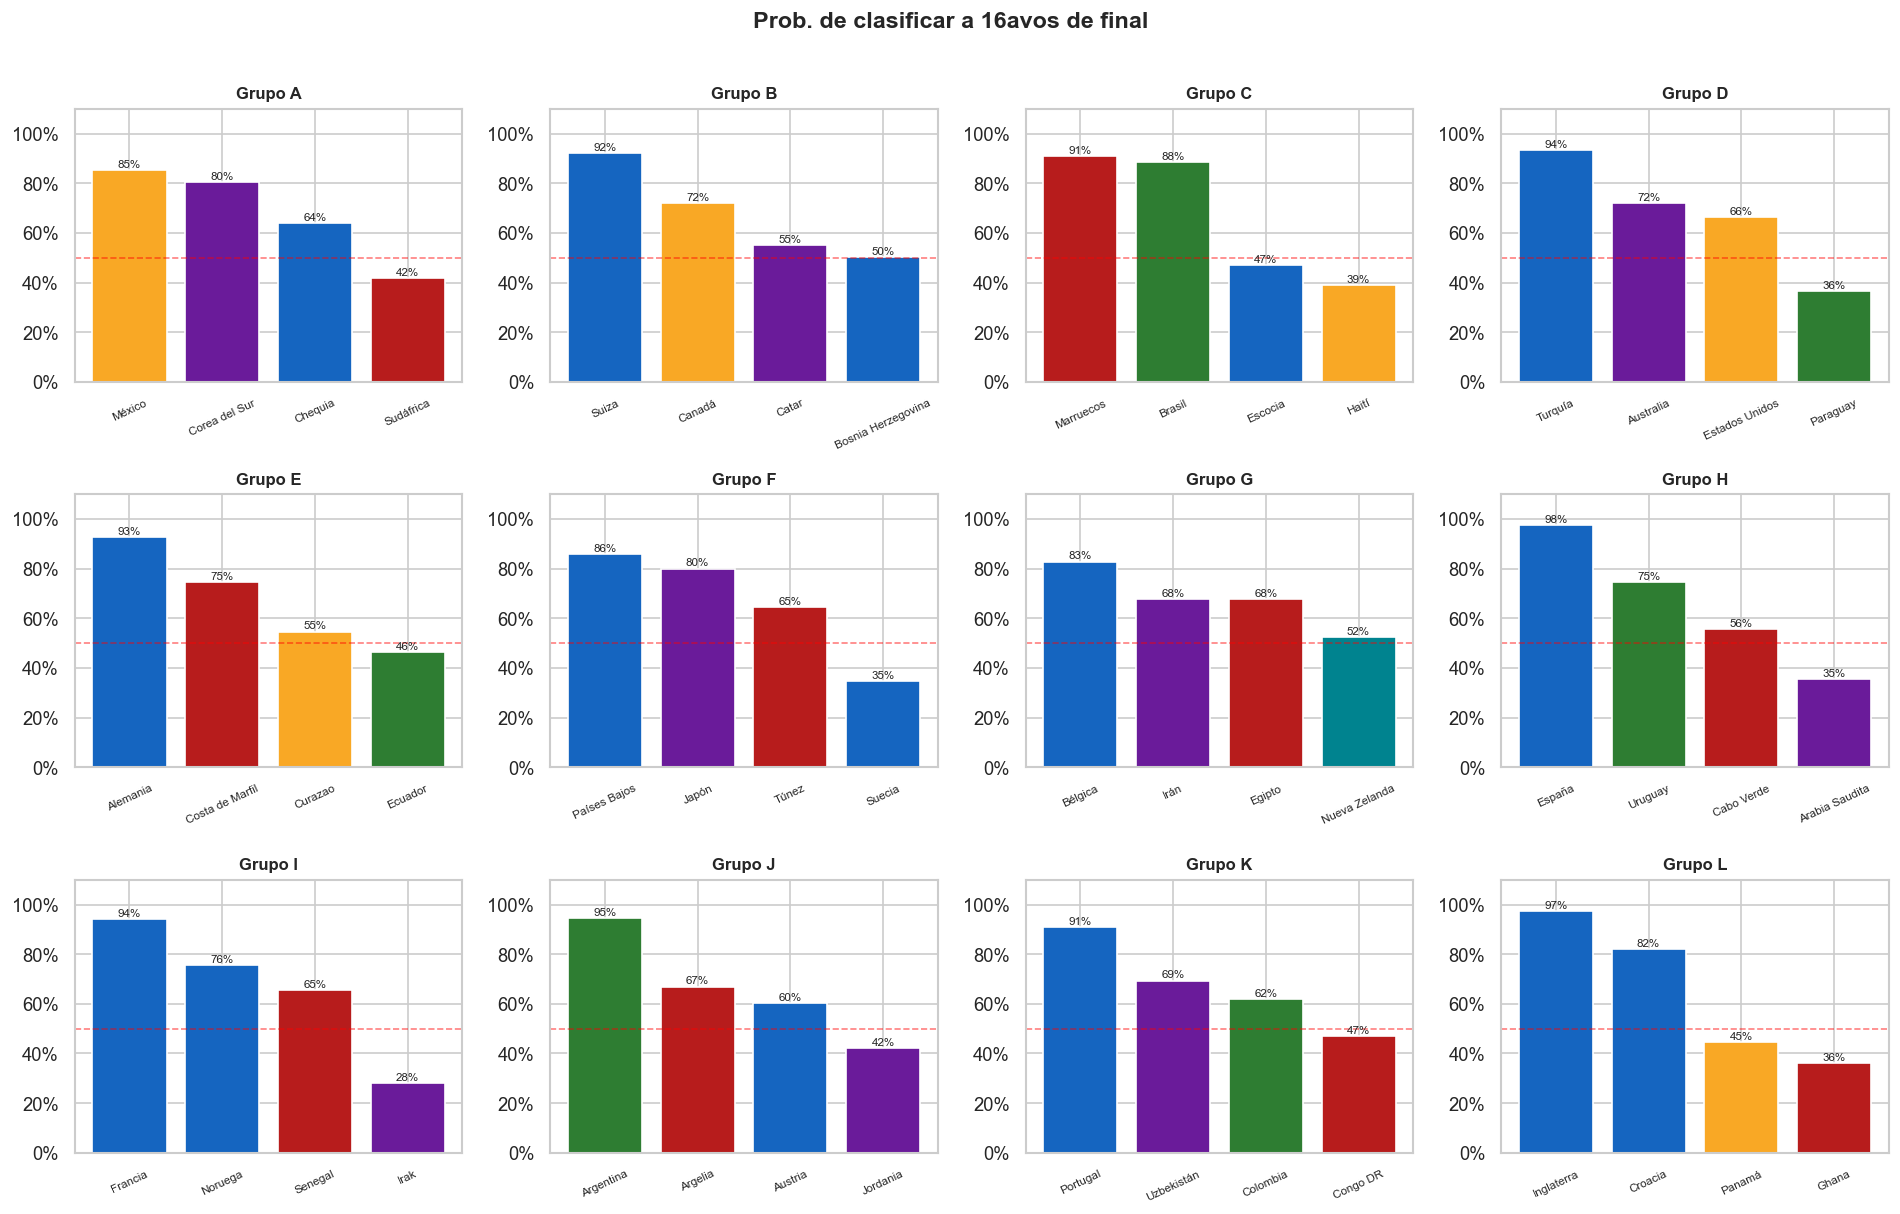

In [12]:
res_g = resultados.merge(equipos_df[["equipo","grupo","confederacion"]], on="equipo")
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()
for i, grupo in enumerate(sorted(grupos.keys())):
    g_df = res_g[res_g["grupo"]==grupo].sort_values("clasifica", ascending=False)
    ax = axes[i]
    cg = [conf_colors.get(c,"#607D8B") for c in g_df["confederacion"]]
    bars2 = ax.bar(g_df["equipo"], g_df["clasifica"]*100, color=cg, edgecolor="white")
    ax.axhline(50, color="red", linestyle="--", alpha=0.5, lw=1)
    ax.set_title(f"Grupo {grupo}", fontweight="bold", fontsize=10)
    ax.set_ylim(0, 110)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.tick_params(axis="x", rotation=25, labelsize=7)
    for bar, val in zip(bars2, g_df["clasifica"]*100):
        ax.text(bar.get_x()+bar.get_width()/2, val+1,
                f"{val:.0f}%", ha="center", fontsize=7)
plt.suptitle("Prob. de clasificar a 16avos de final",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(GRAFICOS / "clasificacion_grupos.png", dpi=150, bbox_inches="tight")
plt.show()


## 11. Resumen ejecutivo

In [13]:
print("="*55)
print("   PREDICCIÓN MUNDIAL 2026")
print("="*55)
print(f"   Simulaciones: {N_SIMS:,} | Modelo: GradientBoosting")
print()
print("   TOP 10 CANDIDATOS AL TÍTULO:")
for _, row in resultados.head(10).iterrows():
    conf = equipo_conf.get(row["equipo"],"")
    print(f'   {row["equipo"]:<22} {row["campeon"]*100:5.1f}%  [{conf}]')
print()
res_conf = resultados.merge(equipos_df[["equipo","confederacion"]], on="equipo")
conf_ch = res_conf.groupby("confederacion")["campeon"].sum().sort_values(ascending=False)
print("   PROB. DE TÍTULO POR CONFEDERACIÓN:")
for conf, prob in conf_ch.items():
    print(f"   {conf:<12} {prob*100:5.1f}%")


   PREDICCIÓN MUNDIAL 2026
   Simulaciones: 10,000 | Modelo: GradientBoosting

   TOP 10 CANDIDATOS AL TÍTULO:
   Inglaterra              10.5%  [UEFA]
   Argentina                9.1%  [CONMEBOL]
   España                   8.7%  [UEFA]
   Francia                  8.5%  [UEFA]
   Japón                    8.4%  [AFC]
   Marruecos                5.0%  [CAF]
   Países Bajos             4.6%  [UEFA]
   Alemania                 4.2%  [UEFA]
   México                   3.5%  [CONCACAF]
   Turquía                  3.4%  [UEFA]

   PROB. DE TÍTULO POR CONFEDERACIÓN:
   UEFA          52.6%
   AFC           15.2%
   CAF           13.5%
   CONMEBOL      12.6%
   CONCACAF       5.1%
   OFC            0.9%
